In [1]:
sigma_error_inter = None
C0_sigma_inter = None
A_sigma_inter = None
z_array = None

import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

import pickle
import os
from datetime import datetime

import emcee
from multiprocess import Pool, cpu_count

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# initial parameters
Hubble0 = 70
e_mu0 = 150
sigma_host0 = 0.5

# MCMC parameters
N_WALKERS = 16
HEATING = 10
N_STEPS = 400

# checkpoint
RESUME = False
CKP_INTERVAL = 50
SAVE_FILE = './DM_ext_checkpoint/simulation_data.pkl'
MCMC_FILE = './DM_ext_checkpoint/mcmc_checkpoint.pkl'

DATA_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

N_EVENTS = 20
REDSHIFT_METHOD = 'rates'  # choose from 'rates', 'uniform', 'gaussian', 'lognormal' and 'powerlaw'

########################################
### Load standard parameters for pdf ###
########################################

S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
HOF=2.813

In [3]:
###################################
### Load interpolations for pdf ###
###################################

def _load_and_create_interpolators():
    load_arrays = np.load(DATA_PATH)
    Sigmas = load_arrays['a']
    Errors = load_arrays['d']
    C0s = load_arrays['c'] 
    As = load_arrays['b']
    
    sigma_error_inter = interpolate.interp1d(Errors, Sigmas, kind=1, bounds_error=False,fill_value='extrapolate')
    C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1, bounds_error=False,fill_value='extrapolate')
    A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1, bounds_error=False,fill_value='extrapolate')
    
    return Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter

Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()

z_array=np.linspace(0.2, 2.0, 1000)

# p_selection = redshift_distribution(z_array=z_array, H0=HUBBLE, Omega_m=OMEGA_MATTER, w, method=REDSHIFT_METHOD)
# p_selection = normalise(p_selection, z_array)

def initialize_globals():
    """Initialize global variables for worker processes"""
    global sigma_error_inter, C0_sigma_inter, A_sigma_inter
    global z_array
    
    if sigma_error_inter is None:
        Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()
        z_array = np.linspace(0.2, 2.0, 1000)
    
#######################
### DL error model ###
#######################

LVK_linear = interpolations['LVK_interpolation']
CE_linear = interpolations['CE_interpolation']

# Find use quadratic function may get negative error in some large redshift

def func_lin(x, a0, a1):
    return a0+a1*x


def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        sigma_ratio = func_lin(z, *LVK_linear)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=1):
    if (order==1):
        sigma_ratio = func_lin(z, *CE_linear)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

In [4]:
#######################
### Generate events ###
#######################

if RESUME and os.path.exists(SAVE_FILE):
    # Load previously saved data
    print(f"Loading data from {SAVE_FILE}...")
    with open(SAVE_FILE, 'rb') as f:
        saved_data = pickle.load(f)
    
    z_centre = saved_data['z_centre']
    dL_obs_centre = saved_data['dL_obs_centre']
    sigma_dL = saved_data['sigma_dL']
    DM_obs_centre = saved_data['DM_obs_centre']
    s_DM_obs = saved_data['s_DM_obs']
    
    # Also load the theoretical values
    dL_centre = saved_data['dL_centre']
    DM_centre = saved_data['DM_centre']
    
    print(f"Successfully loaded {len(z_centre)} events from saved data.")
    
else:
    """ if not RESUME and os.path.exists(SAVE_FILE):
        print(f"RESUME=False: Removing old save data {SAVE_FILE}...")
        os.remove(SAVE_FILE)
    
    if not RESUME and os.path.exists(MCMC_FILE):
        print(f"RESUME=False: Removing old save MCMC checkpoint {MCMC_FILE}...")
        os.remove(MCMC_FILE) """
    
    # Generate new data
    print("Generating new simulation data...")
    
    z_range = np.linspace(0.25, 2.0, 1000)
    z_centre = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, 
                                          N_draws=N_EVENTS, method=REDSHIFT_METHOD)

    # Theoretical dL, fiducial cosmo
    dL_centre = luminosity_distance(z=z_centre, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA)
    # Theoretical DM, fiducial cosmo
    DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)

    ## Choice of observed luminosity distance
    # Use this for fixed error/redshift
    # sigma_dL = 0.1*dL_centre

    # Use this for redshift dependent errors
    sigma_dL = GW_error_CE(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)

    dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

    DM_obs_centre = np.zeros_like(z_centre)
    s_DM_obs = np.zeros_like(z_centre)

    for idx, z_val in enumerate(z_centre):
        print(f"Processing event {idx+1}/{N_EVENTS}...")
        DM_obs_centre[idx], s_DM_obs[idx] = \
            DM_ext_sampling(z=z_val, 
                            S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                            sigma_error_inter=sigma_error_inter,
                            C0_sigma_inter=C0_sigma_inter,
                            A_sigma_inter=A_sigma_inter,
                            Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=2000
                        )
    
    # Save the generated data
    save_data = {
        'z_centre': z_centre,
        'dL_obs_centre': dL_obs_centre,
        'sigma_dL': sigma_dL,
        'DM_obs_centre': DM_obs_centre,
        's_DM_obs': s_DM_obs,
        'dL_centre': dL_centre,
        'DM_centre': DM_centre
    }
    
    """ directory = os.path.dirname(SAVE_FILE)
    if directory:
        os.makedirs(directory, exist_ok=True)
    with open(SAVE_FILE, 'wb') as f:
        pickle.dump(save_data, f)
    
    print(f"Data saved to {SAVE_FILE}") """

Generating new simulation data...
Processing event 1/20...


/tmp/ipykernel_2347/566465565.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  DM_obs_centre[idx], s_DM_obs[idx] = \


Processing event 2/20...
Processing event 3/20...
Processing event 4/20...
Processing event 5/20...
Processing event 6/20...
Processing event 7/20...
Processing event 8/20...
Processing event 9/20...
Processing event 10/20...
Processing event 11/20...
Processing event 12/20...
Processing event 13/20...
Processing event 14/20...
Processing event 15/20...
Processing event 16/20...
Processing event 17/20...
Processing event 18/20...
Processing event 19/20...
Processing event 20/20...


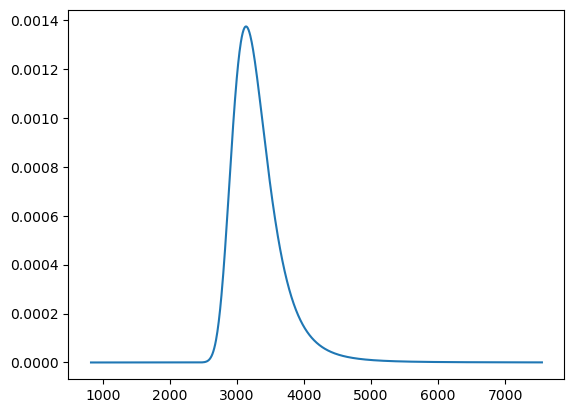

In [5]:
z = 4

DM_th=DM_diff_HOf(z, HOF, Om=OMEGA_MATTER, w=W_LAMBDA)

dm_range=np.linspace(0.25*DM_th, 1000+2.0*DM_th, 1000)
    # np.linspace(0.01, 200+5*DM_th, int_N)


p_range=[
    calculate_dm_probability_num_HOf_fast(
    DM_frb_max=dm,
    z=z,
    S=S,
    HOf=HOF,
    sigma_host=SIGMA_HOST,
    e_mu=EXP_MU,
    f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
    ) for dm in dm_range]

plt.plot(dm_range, p_range)

In [6]:
DM_centre2 = dispersion_measure(z_centre, H0=80, Om=OMEGA_MATTER)
dL_centre2 = luminosity_distance(z=z_centre, H0=80, Om=OMEGA_MATTER, w=W_LAMBDA)

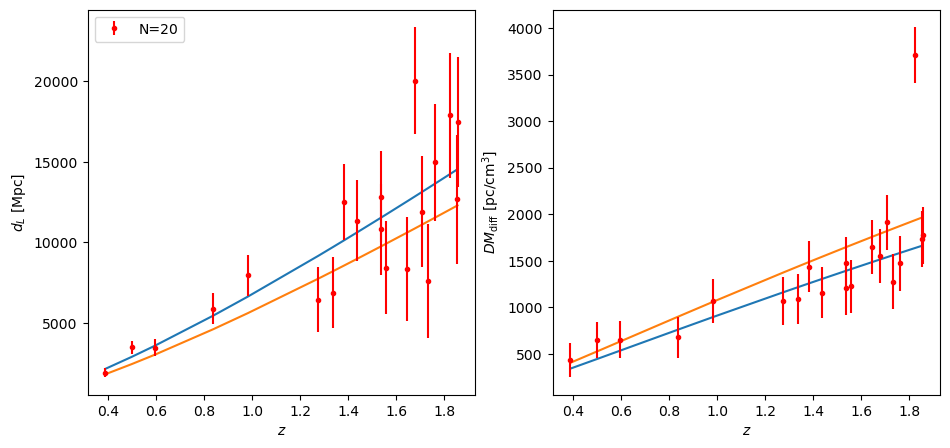

In [7]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.plot(np.sort(z_centre), np.sort(dL_centre2))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre))
ax2.plot(np.sort(z_centre), np.sort(DM_centre2))
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'$DM_{\rm diff}$ [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

# plt.savefig('./plot/dL_DM_diff.png')
# plt.tight_layout()
plt.show()

In [8]:
def log_likelihood(theta, zs, dLs, s_dLs, DMs, s_DMs):
    """
    Calculate the log likelihood for a set of parameters given the data.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data

    Returns:
        Log likelihood
    """
    
    hubble, e_mu, sigma_host = theta

    log_like = 0.0

    try:
        for idx, (z, dL_obs, s_dL, DM_obs, s_DM) in enumerate(zip(zs, dLs, s_dLs, DMs, s_DMs)):
            ####### dL kde ######
            # dL_gaussian = np.random.normal(dL_obs, s_dL, 2000)
            # dL_gaussian = np.maximum(dL_gaussian, 0)
            # GW_dL_kde = gaussian_kde(dL_gaussian)
            
            ######## p_DM(z) and p_dL(z) ########
            
            lum_distance = luminosity_distance(z=z_array, H0=hubble, Om=OMEGA_MATTER, w=W_LAMBDA)
            p_dL = gaussian_pdf(lum_distance, dL_obs, s_dL)
            
            # DM_th_array = e_mu + np.exp(sigma_host**2/2) + dispersion_measure(z=z_array, H0=hubble, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=0, f_IGM_0 = 0.84)
            
            p_DM=np.zeros_like(z_array)
            
            for idx_z, z_val in enumerate(z_array):                
                p_DM[idx_z]=p_dm_ext_fast(DM_ext=DM_obs, z=z_val, 
                                        S=S, e_mu=e_mu, sigma_host=sigma_host, 
                                        f_sigma_error=sigma_error_inter, 
                                        f_C0_sigma=C0_sigma_inter, f_A_sigma=A_sigma_inter, 
                                        space='Delta',
                                        dropna=False, # drop nan value
                                        error_calculator=None, 
                                        H0=hubble, f_diff=0.84, f_diff_alpha=0, # FRB standard parameters
                                        Om=OMEGA_MATTER, w=W_LAMBDA, 
                                        int_N=1000
                                        )
            
            # p_DM=normalise(p_DM, x_array=z_array)
            # p_dL=normalise(GW_dL_kde(lum_distance), x_array=z_array)
            # p_dL=normalise(p_dL, x_array=z_array)
            # prob = np.trapz(p_selection*p_dL*p_DM, z_array)
            # integrand = p_selection * p_dL * p_DM
            # p_event = normalise(p_dL * p_DM, z_array)
            p_selection = redshift_distribution(z_array=z_array, H0=hubble, Omega_m=OMEGA_MATTER, w=W_LAMBDA, method=REDSHIFT_METHOD)
            p_selection = normalise(p_selection, z_array)
            
            integrand = p_selection * p_DM * p_dL
            prob = np.trapz(integrand, z_array)
            
            if prob > 1e-300:
                log_like += np.log(prob)
            else:
                print(f"Warning: prob={prob:.2e} for event {idx}, theta={theta}")
                return -np.inf

        return log_like

    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        import traceback
        traceback.print_exc()
        return -np.inf


def log_prior(theta):
    """
    Calculate the log of the prior probability for a set of parameters.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]

    Returns:
        Log prior probability
    """
    hubble, e_mu, sigma_host = theta

    # Define your prior ranges here
    hubble_min, hubble_max = 40, 100 #0.016 # 0.2 # 2.0 #0.2 # Example range, adjust based on your model
    e_mu_min, e_mu_max = 50, 250  # Example range, adjust based on your model
    sigma_host_min, sigma_host_max = 0.01, 2.0  # Example range

    # Check if parameters are within prior ranges
    if (hubble_min <= hubble <= hubble_max and 
        e_mu_min <= e_mu <= e_mu_max and 
        sigma_host_min <= sigma_host <= sigma_host_max ):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf  # Log(0) = -inf, outside prior range       

def log_probability(theta, zs, dLs, s_dLs, DMs, s_DMs):
    """
    Calculate the log probability (posterior) for a set of parameters.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data

    Returns:
        Log posterior probability
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(theta, zs, dLs, s_dLs, DMs, s_DMs)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


### checkpoint ###

def save_checkpoint(sampler, step, state, filename="mcmc_checkpoint.pkl"):
    """
    Save MCMC checkpoint to file.
    
    Args:
        sampler: emcee sampler object
        step: Current step number
        state: Current state of the sampler
        filename: Checkpoint filename
    """
    checkpoint = {
        'step': step,
        'chain': sampler.chain,
        'log_prob': sampler.lnprobability,
        'acceptance_fraction': sampler.acceptance_fraction,
        'state_coords': state.coords if state is not None else None,
        'state_log_prob': state.log_prob if state is not None else None,
        'state_blobs': state.blobs if state is not None else None,
        'state_random_state': state.random_state if state is not None else None,
        'timestamp': datetime.now().isoformat()
    }
    
    # Save to temporary file first, then rename (atomic operation)
    temp_filename = filename + ".tmp"
    with open(temp_filename, 'wb') as f:
        pickle.dump(checkpoint, f)
    os.rename(temp_filename, filename)
    print(f"Checkpoint saved at step {step}")


def load_checkpoint(filename="mcmc_checkpoint.pkl"):
    """
    Load MCMC checkpoint from file.
    
    Args:
        filename: Checkpoint filename
        
    Returns:
        checkpoint dict or None if file doesn't exist
    """
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            checkpoint = pickle.load(f)
        print(f"Checkpoint loaded from step {checkpoint['step']}")
        print(f"Saved at: {checkpoint['timestamp']}")
        return checkpoint
    return None


def run_mcmc_checkpoint(initial_params, zs, dLs, s_dLs, DMs, s_DMs, 
             nwalkers=32, heating=10, nsteps=2000, 
             checkpoint_interval=50, checkpoint_file=MCMC_FILE,
             resume=RESUME):
    """
    Run the MCMC analysis with checkpoint support.

    Args:
        initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
        zs, dLs, s_dLs, DMs, s_DMs: Data arrays
        nwalkers: Number of walkers
        heating: Number of heating steps
        nsteps: Number of steps per walker
        checkpoint_interval: Save checkpoint every N steps
        checkpoint_file: Checkpoint filename
        resume: If True, try to resume from checkpoint

    Returns:
        sampler: emcee sampler object with results
    """

    ndim = len(initial_params)
    
    # Try to load checkpoint if resume=True
    checkpoint = None
    if resume:
        checkpoint = load_checkpoint(checkpoint_file)
    
    # Initialize or resume
    if checkpoint is not None:
        # Resume from checkpoint
        start_step = checkpoint['step']
        
        # Recreate sampler and restore state
        with Pool(initializer=initialize_globals) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(zs, dLs, s_dLs, DMs, s_DMs,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.8),
                       (emcee.moves.DESnookerMove(), 0.2)]
            )
            
            # Restore chain history
            sampler._chain = checkpoint['chain']
            sampler._lnprob = checkpoint['log_prob']
            sampler._acceptance_fraction = checkpoint['acceptance_fraction']
            
            # Recreate state object
            from emcee.state import State
            state = State(
                checkpoint['state_coords'],
                log_prob=checkpoint['state_log_prob'],
                blobs=checkpoint['state_blobs'],
                random_state=checkpoint['state_random_state']
            )
            
            remaining_steps = nsteps - start_step
            
            if remaining_steps <= 0:
                print("MCMC already completed!")
                return sampler
                
            print(f"Resuming from step {start_step}, {remaining_steps} steps remaining")
            
            # Continue main running
            print("Continuing main running...")
            with tqdm(initial=start_step, total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, 
                                                         iterations=remaining_steps,
                                                         store=True)):
                    current_step = start_step + i + 1
                    pbar.update(1)
                    state = result
                    
                    # Save checkpoint
                    if current_step % checkpoint_interval == 0:
                        save_checkpoint(sampler, current_step, state, checkpoint_file)
                    
                    # Check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                        
                        if i > 500 and acc_frac < 0.001:
                            print("Warning: acceptance fraction too low")
    
    else:
        # Start from beginning
        print("Starting new MCMC run...")
        
        # Set initial positions with small random offsets
        pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
        
        for i in range(nwalkers):
            while log_prior(pos[i]) == -np.inf:
                pos[i] = initial_params + 0.01 * np.random.randn(ndim)
        
        with Pool(initializer=initialize_globals) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(zs, dLs, s_dLs, DMs, s_DMs,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.8),
                       (emcee.moves.DESnookerMove(), 0.2)]
            )
            
            # Heating phase
            print("Heating...")
            state = None
            with tqdm(total=heating) as pbar:
                for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                    pbar.update(1)
                    state = result
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
            
            # Reset sampler after heating
            sampler.reset()
            
            # Main running phase
            print("Main running...")
            with tqdm(total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, 
                                                         iterations=nsteps,
                                                         store=True)):
                    pbar.update(1)
                    state = result
                    current_step = i + 1
                    
                    # Save checkpoint
                    if resume:
                        if current_step % checkpoint_interval == 0:
                            save_checkpoint(sampler, current_step, state, checkpoint_file)
                    
                    # Check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                        
                        if i > 500 and acc_frac < 0.001:
                            print("Warning: acceptance fraction too low")
    
    # Final save
    if resume:
        save_checkpoint(sampler, nsteps, state, checkpoint_file)
    
    # Check final acceptance fraction
    final_acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"Final acceptance fraction: {final_acc_frac:.3f}")
    
    if final_acc_frac < 0.01:
        print("Warning: acceptance fraction too low")
    
    return sampler

In [9]:
def mcmc_analyze_results(sampler, burn_in=10, thin=15, target_prob=0.6827):
    """
    Analyze the MCMC results.
    
    Args:
        sampler: emcee sampler with results
        burn_in: Number of initial steps to discard
        thin: Thinning factor for samples
    
    Returns:
        samples: Flattened, burned-in, and thinned samples
        params_median: Median parameter values
        params_errors: Parameter uncertainties (16th and 84th percentiles)
    """
    # Discard burn-in, flatten and thin the samples
    flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    
    # Calculate the median and 16th and 84th percentiles for the parameters
    params_median = np.median(flat_samples, axis=0)
    params_lower = np.percentile(flat_samples, 50-target_prob*50, axis=0) # np.percentile(flat_samples, 16, axis=0)
    params_upper = np.percentile(flat_samples, 50+target_prob*50, axis=0) #np.percentile(flat_samples, 84, axis=0)
    
    # Calculate errors
    params_errors = [(params_upper[i] - params_lower[i]) / 2 for i in range(len(params_median))]
    
    return flat_samples, params_median, params_errors

def mcmc_plot_results(samples, param_names, savetitle=None, bins=30, target_prob=0.6827):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    
    # Create corner plot
    
    fig = corner.corner(
        samples, 
        labels=param_names,
        quantiles=[0.5-target_prob/2, 0.5, 0.5+target_prob/2], # [0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        title_fmt='.3f',
        bins=bins,
        smooth=True,
        color='tab:blue'
    )
    
    if savetitle is not None:
        plt.savefig(savetitle+"_corner_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Plot chains for each parameter
    fig, axes = plt.subplots(len(param_names), 1, figsize=(10, 2*len(param_names)), sharex=True)
    
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        ax.plot(samples[:, i], 'k-', alpha=0.3)
        ax.set_ylabel(name)
        if i == (len(param_names)-1):
            ax.set_xlabel("Sample Number")
    
    plt.tight_layout()
    if savetitle is not None:
        plt.savefig(savetitle+"_chains.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# 20 events

if __name__ == '__main__':
    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([Hubble0, e_mu0, sigma_host0])

    # Run MCMC
    """ sampler = run_mcmc(initial_params, 
                   zs=z_centre, dLs=dL_obs_centre, s_dLs=sigma_dL, DMs=DM_obs_centre, s_DMs=s_DM_obs, 
                   nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS) """
    sampler = run_mcmc_checkpoint(initial_params, 
                   zs=z_centre, dLs=dL_obs_centre, s_dLs=sigma_dL, DMs=DM_obs_centre, s_DMs=s_DM_obs, 
                   nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS,
                   checkpoint_interval=CKP_INTERVAL, checkpoint_file=MCMC_FILE,resume=RESUME)
    
    # Analyze results
    samples, params_median, params_errors = mcmc_analyze_results(sampler, burn_in=HEATING)

    # Print results
    param_names = [r'$ H_0$ ', r'$ exp(\mu)$ ', r'$ \sigma_{\rm host}$ ']
    print("MCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

    # Save samples to file for later analysis if needed
    # np.save('./posterior/GW_FRB_MCMC_DM_ext.npy', samples)

    mcmc_plot_results(samples, param_names, savetitle=None)

Starting new MCMC run...
Heating...


Acceptance fraction: 0.812: 100%|██████████| 10/10 [01:56<00:00, 11.65s/it]


Main running...


Acceptance fraction: 0.225:  70%|██████▉   | 278/400 [34:44<17:01,  8.37s/it] 